In [9]:
# Importando as bibliotecas
import pandas as pd
from pandasql import sqldf
import sqlite3
import matplotlib.pyplot as plt

In [10]:
# Seleção de dados (dataframe)
df = pd.read_csv("C:/Users/rodol/OneDrive/Área de Trabalho/Analise de Dados/analise-vendas-superstore/data/dataset_sales.csv")

In [11]:
# Quantidade de linhas e colunas
print(df.shape)

(9800, 18)


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [13]:
# Produz múltiplicas sínteses estatísticas
print(df.describe())

            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


In [14]:
#Receita total de vendas
df["Sales"].sum

<bound method Series.sum of 0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9795      3.7980
9796     10.3680
9797    235.1880
9798     26.3760
9799     10.3840
Name: Sales, Length: 9800, dtype: float64>

In [57]:
# Categoria mais vendida
df.groupby("Category")["Sales"].sum()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

In [58]:
# Estado com o maior faturamento
df.groupby("State")["Sales"].sum().sort_values(ascending=False)

State
California              446306.4635
New York                306361.1470
Texas                   168572.5322
Washington              135206.8500
Pennsylvania            116276.6500
Florida                  88436.5320
Illinois                 79236.5170
Michigan                 76136.0740
Ohio                     75130.3500
Virginia                 70636.7200
North Carolina           55165.9640
Indiana                  48718.4000
Georgia                  48219.1100
Kentucky                 36458.3900
Arizona                  35272.6570
New Jersey               34610.9720
Colorado                 31841.5980
Wisconsin                31173.4300
Tennessee                30661.8730
Minnesota                29863.1500
Massachusetts            28634.4340
Delaware                 27322.9990
Maryland                 23705.5230
Rhode Island             22525.0260
Missouri                 22205.1500
Oklahoma                 19683.3900
Alabama                  19510.6400
Oregon                

In [59]:
# Criando o banco de dados
conexao = sqlite3.connect('dados_exercicio.db')

In [60]:
# Enviando o dataframe atual para dentro do banco de dados
df.to_sql('vendas', conexao, if_exists='replace', index=False)

9800

In [61]:
print(df.shape)

(9800, 18)


In [62]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [63]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [64]:
# Receita total
df["Sales"].sum()

2261536.7827000003

In [18]:
## Introduzindo a Estatistica
# A média de vendas foi 230.7690594591837.
df["Sales"].mean()

230.7690594591837

In [19]:
# Maior venda
df["Sales"].max()

22638.48

In [20]:
# Menor venda
df["Sales"].min()

0.444

In [26]:
# A mediana foi 54.489999999999995
df["Sales"].median()

54.489999999999995

In [28]:
# O desvio padrão sugere alta dispersão de valores
df["Sales"].std()

626.6518748388047

In [65]:
# Função que permite rodar SQL apenas escrevendo rodar_sql("SEU COMANDO")
rodar_sql = lambda q: sqldf(q, globals())

In [66]:
# Lucro total Estimado
query_1 = """
SELECT
    State,
    SUM(Sales * 0.40) AS lucro_total_estimado
from df
GROUP BY State;
"""
rodar_sql(query_1)

,State,lucro_total_estimado
0,Alabama,7804.25600
1,Arizona,14109.06280
2,Arkansas,4671.25200
3,California,178522.58540
4,Colorado,12736.63920
5,Connecticut,5353.74280
6,Delaware,10929.19960
7,District of Columbia,1146.00800
8,Florida,35374.61280
9,Georgia,19287.64400


In [67]:
# Categoria mais lucrativa (Maior lucro estimado)
query_2 = """
SELECT 
    Category, 
    SUM(Sales * 0.40) AS lucro_por_categoria
FROM df
GROUP BY Category
ORDER BY lucro_por_categoria DESC
LIMIT 1;
"""
rodar_sql(query_2)

,Category,lucro_por_categoria
0,Technology,330982.3492


In [68]:
# Estado mais lucrativo (Maior lucro estimado)
query_3 = """
SELECT 
    State, 
    SUM(Sales * 0.40) AS lucro_por_estado
FROM df
GROUP BY State
ORDER BY lucro_por_estado DESC
LIMIT 1;
"""
rodar_sql(query_3)

,State,lucro_por_estado
0,California,178522.5854


In [69]:
# Vendas por categoria
vendas_categoria = (df.groupby("Category")["Sales"].sum().sort_values())

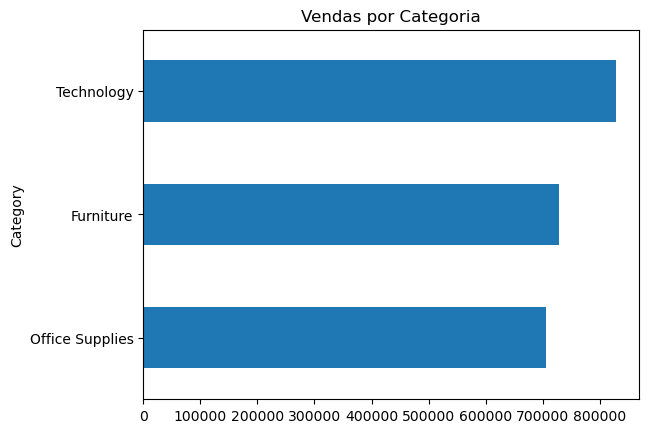

In [71]:
vendas_categoria.plot(kind="barh")
plt.title("Vendas por Categoria")
plt.show()

In [75]:
# Top 10 Estados (Por Faturamento)
top_estados = (df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10))

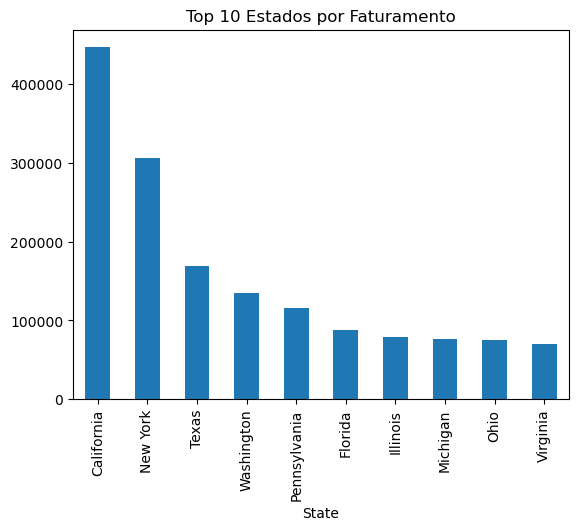

In [76]:
top_estados.plot(kind="bar")
plt.title("Top 10 Estados por Faturamento")
plt.show()

In [30]:
# Storyteling para dados
## Top 10 produtos por receita
top_produtos = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_produtos)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [31]:
## Top 10 estados por receita
top_estados = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_estados)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [32]:
## Categoria mais lucrativa
df.groupby("Category")["Profit"].sum()

KeyError: 'Column not found: Profit'